In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import ( 
accuracy_score, precision_score, recall_score, f1_score, 
confusion_matrix, classification_report 
) 
# Bayesian Network Libraries
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

In [34]:
df = pd.read_csv('sample_data.csv')
print(df.head())

   Hours_Studied  Attendance  Prev_score  Final_marks  Pass
0              2          60          45           48     0
1              3          62          47           50     0
2              4          65          50           52     0
3              5          68          52           55     0
4              6          70          55           58     0


In [35]:
X = df[['Hours_Studied', 'Attendance', 'Prev_score', 'Final_marks']] 
y = df['Pass'] 

In [36]:
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.2, random_state=42, stratify=y 
) 

In [37]:
bn_train = X_train.copy() 
bn_train['Pass'] = y_train 
bn_test = X_test.copy() 
bn_test['Pass'] = y_test

In [38]:
h_bins = pd.qcut(bn_train['Hours_Studied'], q=3, retbins=True, labels=[0,1,2])[1]
a_bins = pd.qcut(bn_train['Attendance'], q=3, retbins=True, labels=[0,1,2])[1]
p_bins = pd.qcut(bn_train['Prev_score'], q=3, retbins=True, labels=[0,1,2])[1]
f_bins = pd.qcut(bn_train['Final_marks'], q=3, retbins=True, labels=[0,1,2])[1]

In [39]:
bn_train['Hours_Studied'] = pd.cut(bn_train['Hours_Studied'], bins=h_bins, labels=[0,1,2], include_lowest=True)
bn_train['Attendance'] = pd.cut(bn_train['Attendance'], bins=a_bins, labels=[0,1,2], include_lowest=True)
bn_train['Prev_score'] = pd.cut(bn_train['Prev_score'], bins=p_bins, labels=[0,1,2], include_lowest=True)
bn_train['Final_marks'] = pd.cut(bn_train['Final_marks'], bins=f_bins, labels=[0,1,2], include_lowest=True)

bn_test['Hours_Studied'] = pd.cut(bn_test['Hours_Studied'], bins=h_bins, labels=[0,1,2], include_lowest=True)
bn_test['Attendance'] = pd.cut(bn_test['Attendance'], bins=a_bins, labels=[0,1,2], include_lowest=True)
bn_test['Prev_score'] = pd.cut(bn_test['Prev_score'], bins=p_bins, labels=[0,1,2], include_lowest=True)
bn_test['Final_marks'] = pd.cut(bn_test['Final_marks'], bins=f_bins, labels=[0,1,2], include_lowest=True)

In [40]:
bn_train = bn_train.astype(int)
bn_test = bn_test.astype(int)

In [41]:
model = DiscreteBayesianNetwork([ 
('Hours_Studied', 'Pass'), 
('Attendance', 'Pass'), 
('Prev_score', 'Pass'), 
('Final_marks', 'Pass') 
]) 

In [42]:
model.fit(bn_train, estimator=BayesianEstimator, prior_type="BDeu")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Hours_Studied': 'N', 'Attendance': 'N', 'Prev_score': 'N', 'Final_marks': 'N', 'Pass': 'N'}


In [43]:
infer = VariableElimination(model) 

In [44]:
y_pred = []

for _, row in bn_test.iterrows():
    evidence = {
        'Hours_Studied': row['Hours_Studied'],
        'Attendance': row['Attendance'],
        'Prev_score': row['Prev_score'],
        'Final_marks': row['Final_marks']
    }
    
    query = infer.query(variables=['Pass'], evidence=evidence)
    pred = np.argmax(query.values)
    y_pred.append(pred)

y_pred = np.array(y_pred)

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred)) 

print("\nClassification Report:\n", 
classification_report(y_test, y_pred, zero_division=0)) 

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) 

Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      0.67      0.67         3

    accuracy                           0.50         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.50      0.50      0.50         4


Confusion Matrix:
 [[0 1]
 [1 2]]


In [46]:
input_data = {'Hours_Studied': 9, 'Attendance': 78, 'Prev_score': 62, 'Final_marks': 70}

input_disc = {
    'Hours_Studied': int(pd.cut([input_data['Hours_Studied']], bins=h_bins, labels=[0,1,2], include_lowest=True)[0]),
    'Attendance': int(pd.cut([input_data['Attendance']], bins=a_bins, labels=[0,1,2], include_lowest=True)[0]),
    'Prev_score': int(pd.cut([input_data['Prev_score']], bins=p_bins, labels=[0,1,2], include_lowest=True)[0]),
    'Final_marks': int(pd.cut([input_data['Final_marks']], bins=f_bins, labels=[0,1,2], include_lowest=True)[0])
}

In [ ]:
query = infer.query(variables=['Pass'], evidence=input_disc)
predicted_class = np.argmax(query.values)

print("\nPredicted Class:", predicted_class)
print("Probablities:", query.values)


Predicted Pass: 1
Probabilities: [0.20365854 0.79634146]


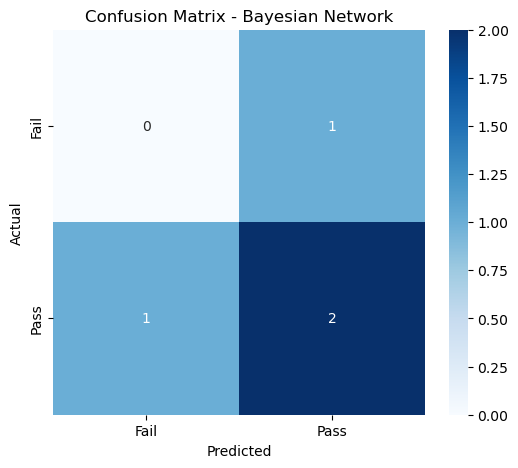

In [48]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bayesian Network")
plt.show()

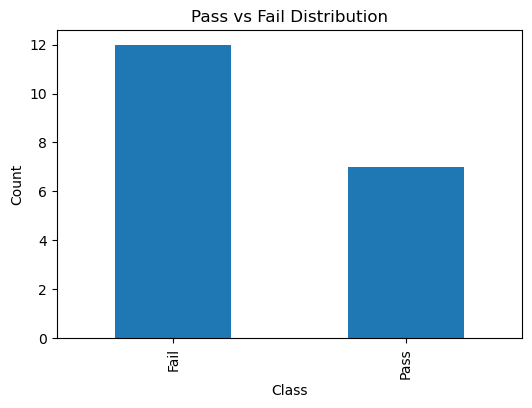

In [49]:
plt.figure(figsize=(6,4))
df['Pass'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['Fail','Pass'])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Pass vs Fail Distribution")
plt.show()

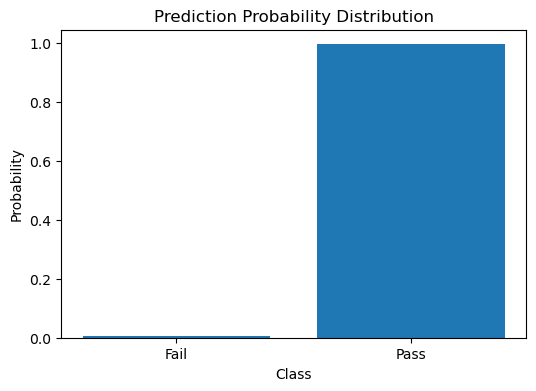

In [50]:
sample = bn_test.iloc[0]

evidence = {
    'Hours_Studied': sample['Hours_Studied'],
    'Attendance': sample['Attendance'],
    'Prev_score': sample['Prev_score'],
    'Final_marks': sample['Final_marks']
}

query = infer.query(variables=['Pass'], evidence=evidence)

plt.figure(figsize=(6,4))
plt.bar(['Fail','Pass'], query.values)

plt.xlabel("Class")
plt.ylabel("Probability")
plt.title("Prediction Probability Distribution")
plt.show()

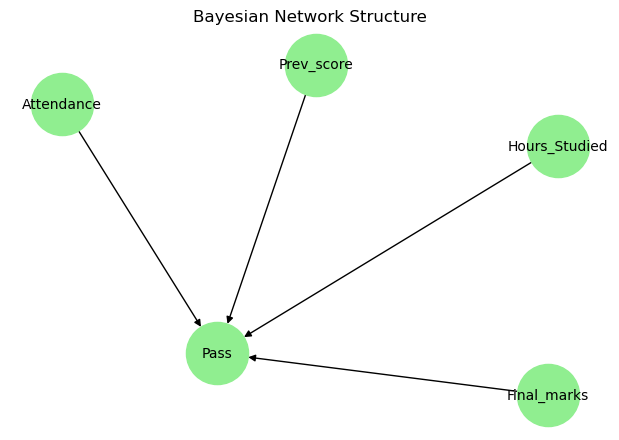

In [51]:
import networkx as nx

# Convert Bayesian model to NetworkX graph
G = nx.DiGraph()
G.add_edges_from(model.edges())

plt.figure(figsize=(6,4))

# Use safe layout (VERY IMPORTANT)
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True,
        node_color='lightgreen',
        node_size=2000,
        font_size=10,
        arrows=True)

plt.title("Bayesian Network Structure")
plt.show()